In [1]:
from scripts.process_log_folder import *
from scripts.quaternions_utilities import *
from scripts import visualizations
from scripts import statistics
from scripts.process_eye_quaternions import *
from importlib import reload
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

## Load trials data

In [2]:
from pathlib import Path

# Define a folder and a file
folder_path = Path("../Logs")

In [3]:
df_step, df_eyetrack = process_log_folder(folder_path)

Processing participants: 100%|██████████| 20/20 [00:02<00:00,  8.68it/s]


# Gaze Tracking

### Preprocessing

In [4]:
# Compute yaw and pitch (degrees) 
df_eyetrack = add_eye_yaw_pitch(df_eyetrack)

# Sort and compute time since trial start 
df_eyetrack = df_eyetrack.sort_values(by=['trial', 'timeSinceStartup'])
df_eyetrack['timeSinceTrialStart'] = (
    df_eyetrack.groupby('trial')['timeSinceStartup']
    .transform(lambda x: x - x.min())
)

# Drop rows missing ANY key experimental variable 

df_eyetrack_preprocessed = df_eyetrack.dropna(
    subset=['condition', 'position', 'lateralisation', 'nb_dist', 'participant'],
    how='any'   
)

# UNWRAP BEFORE CLEANING (comment for dwell analysis, don't comment for analysis of gaze dispersion)
'''
for col in ["lEyeYaw", "rEyeYaw", "lEyePitch", "rEyePitch"]:
    df_eyetrack_preprocessed[col] = (
        df_eyetrack_preprocessed.groupby("trial")[col]
        .transform(lambda y: np.unwrap(y.to_numpy(), discont=180, period=360))
    )
'''
# Remove trials with excessive tracking dropout 

def clean_eye_yaw(df, tol=0.5, eye="Right"):
    """
    Removes trials where eye yaw is 0 for more than `tol` proportion of frames,
    indicating tracking dropout. Sets affected eye yaw to NaN, then drops only
    rows where the relevant eye yaw column is NaN.

    Parameters
    ----------
    df  : DataFrame with columns rEyeYaw / lEyeYaw and 'trial'
    tol : dropout threshold (default 0.5 = exclude trials >50% zeros)
    eye : "Right" or "Left"
    """
    cleaned_df = df.copy()
    trials = cleaned_df['trial'].unique()
    trials_cleaned = 0
    eye_col = 'rEyeYaw' if eye == "Right" else 'lEyeYaw'

    for trial in trials:
        trial_mask  = cleaned_df['trial'] == trial
        trial_data  = cleaned_df.loc[trial_mask, eye_col]
        total_frames = len(trial_data)
        zero_frames  = (trial_data == 0).sum()

        if total_frames > 0 and (zero_frames / total_frames) > tol:
            cleaned_df.loc[trial_mask, eye_col] = np.nan
            trials_cleaned += 1

    
    cleaned_df = cleaned_df.dropna(subset=[eye_col])

    print(
        f"Cleaned {trials_cleaned} / {len(trials)} trials "
        f"({(trials_cleaned / len(trials)) * 100:.2f}%) "
        f"due to >{int(tol*100)}% zero {eye_col} values."
    )
    return cleaned_df


df_eyetrack_preprocessed = clean_eye_yaw(df_eyetrack_preprocessed, tol=0.5)

# Remove incorrect trials 
nb_trials_before = df_eyetrack_preprocessed['trial'].nunique()
df_eyetrack_preprocessed = df_eyetrack_preprocessed[
    df_eyetrack_preprocessed['correct'] == True
]
nb_trials_after = df_eyetrack_preprocessed['trial'].nunique()
print(f"Trials removed (incorrect responses): {nb_trials_before - nb_trials_after}")

# Remove participant 24 
# Excluded due to excessive tracking dropout throughout the session
# (data quality check: >50% of trials flagged in clean_eye_yaw).
nb_trials_before = df_eyetrack_preprocessed['trial'].nunique()
df_eyetrack_preprocessed = df_eyetrack_preprocessed[
    df_eyetrack_preprocessed['participant'] != '24'
]
nb_trials_after = df_eyetrack_preprocessed['trial'].nunique()
print(f"Trials removed (participant 24 excluded): {nb_trials_before - nb_trials_after}")

# Lateralisation normalisation 
# For left-lateralised trials, flip the sign of yaw so that:
#   positive yaw = gaze toward the target/distractor side
#   negative yaw = gaze away from the target/distractor side

df_eyetrack_preprocessed_merged = df_eyetrack_preprocessed.copy()
left_mask = df_eyetrack_preprocessed_merged['lateralisation'] == "Left"
df_eyetrack_preprocessed_merged.loc[left_mask, ['rEyeYaw', 'lEyeYaw']] *= -1

# Final data quality report 
print("\n=== Preprocessing Summary ===")
print(f"Participants retained : {df_eyetrack_preprocessed_merged['participant'].nunique()}")
print(f"Trials retained       : {df_eyetrack_preprocessed_merged['trial'].nunique()}")
print(f"Total rows (frames)   : {len(df_eyetrack_preprocessed_merged)}")
print("\nRows per condition cell:")
print(
    df_eyetrack_preprocessed_merged
    .groupby(['position', 'nb_dist', 'condition'])
    .size()
    .reset_index(name='n_frames')
    .to_string(index=False)
)

Cleaned 88 / 3075 trials (2.86%) due to >50% zero rEyeYaw values.
Trials removed (incorrect responses): 74
Trials removed (participant 24 excluded): 129

=== Preprocessing Summary ===
Participants retained : 19
Trials retained       : 2784
Total rows (frames)   : 187581

Rows per condition cell:
position  nb_dist condition  n_frames
   Front  One_far   Invalid      3437
   Front  One_far     Valid     12824
   Front One_near   Invalid      3639
   Front One_near     Valid     13320
   Front    Three   Invalid      3475
   Front    Three     Valid     13518
   Front     Zero   Invalid      3611
   Front     Zero     Valid     12811
    Rear  One_far   Invalid      7135
    Rear  One_far     Valid     25398
    Rear One_near   Invalid      6813
    Rear One_near     Valid     21631
    Rear    Three   Invalid      5900
    Rear    Three     Valid     25074
    Rear     Zero   Invalid      7306
    Rear     Zero     Valid     21689


### Gaze distribution

#### Figures

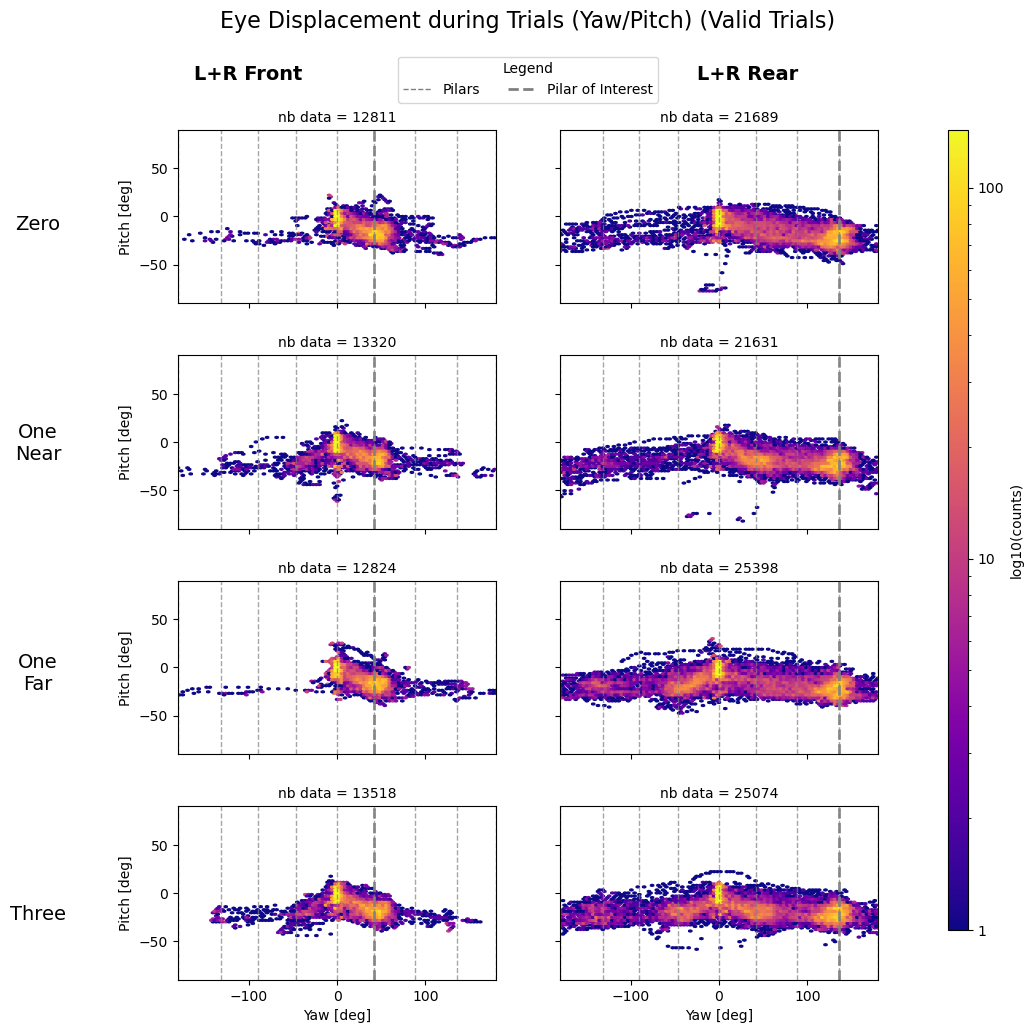

In [5]:
#Figure 5

# heatmap of eye positions during trials
reload(visualizations)
fig, axes, mapping = visualizations.plot_eye_displacement_by_distractors(
    df_eyetrack_preprocessed,
    eye="Right",
    condition=("Valid"), #change here "Invalid" for invalid trials
    log_scale=50,
    show=True,
    merge_left_right=True,
    gridsize_hex=100,
    savepath='fig/heatmap.svg'
)

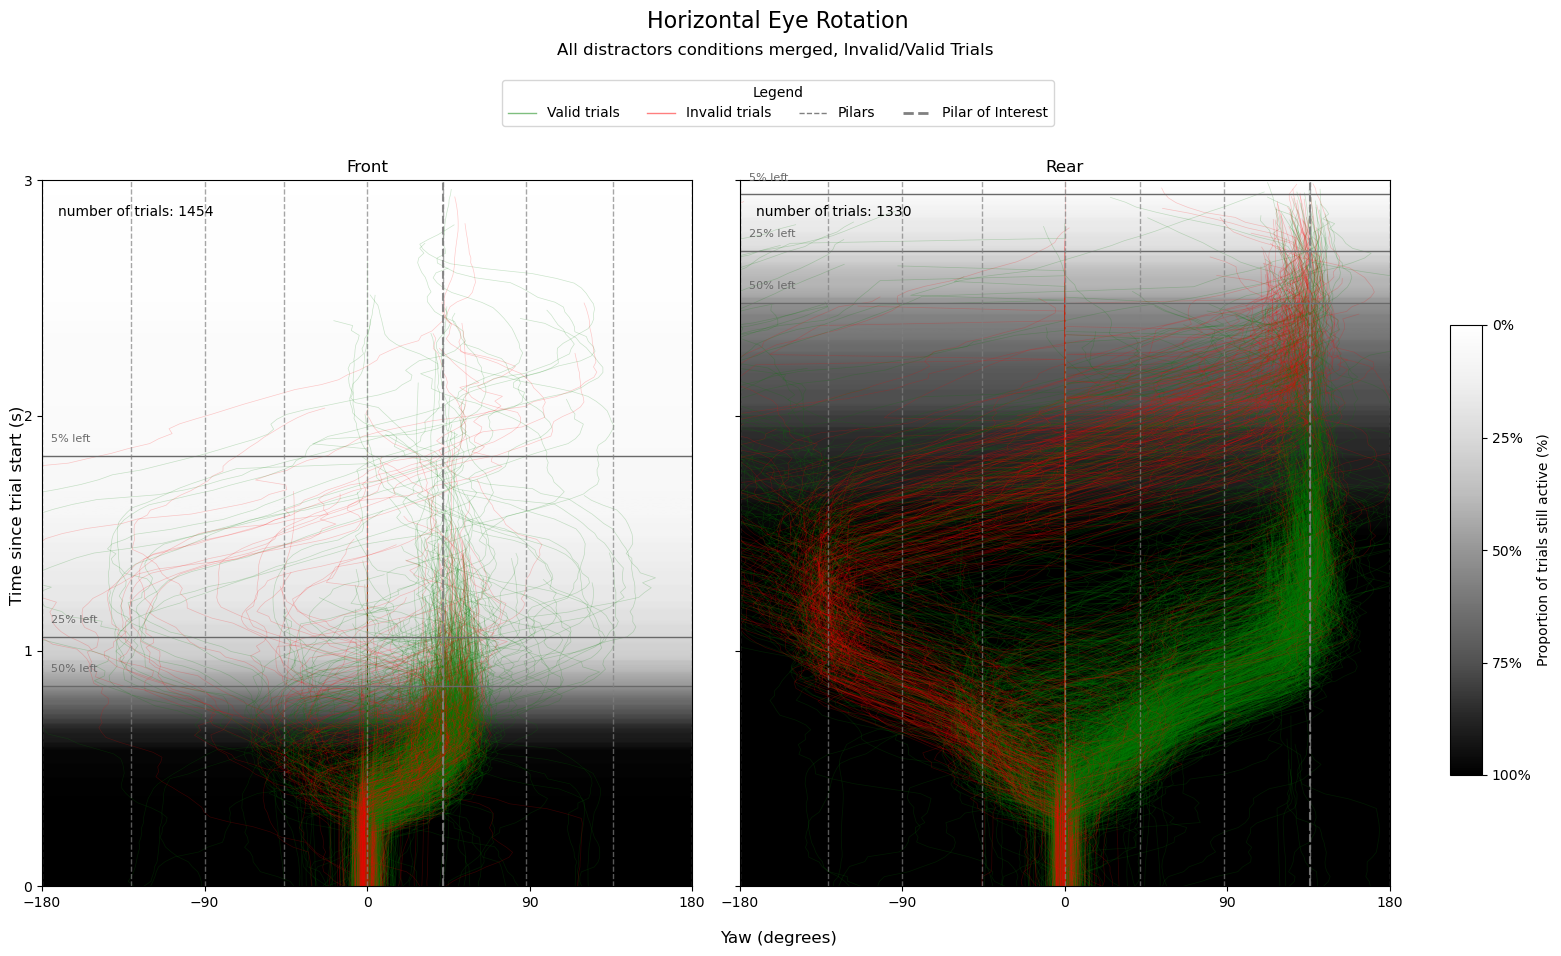

(<Figure size 1600x900 with 3 Axes>,
 array([<Axes: title={'center': 'Front'}>,
        <Axes: title={'center': 'Rear'}>], dtype=object))

In [6]:
#Figure 6

reload(visualizations)
visualizations.plot_temporal_y_rotation_condition(df_eyetrack_preprocessed, condition=["Valid","Invalid"],alpha=0.2, show=True, merge_left_right=True)


C:\Users\deschane\AppData\Local\Temp\ipykernel_23848\2494770613.py:11: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


Figure saved successfully!


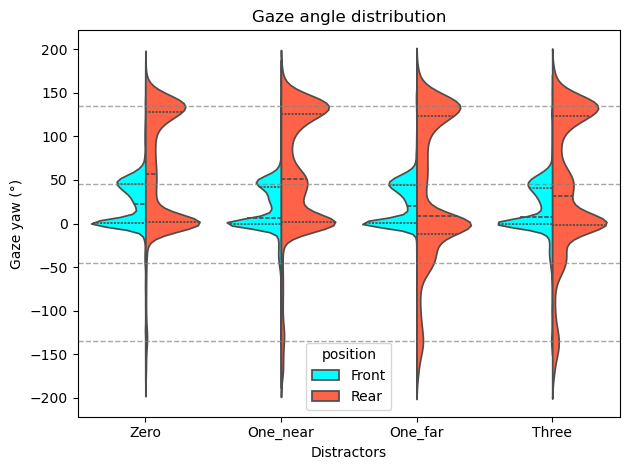

In [ ]:
#Figure 7

# Violin plot distribution of gaze

import seaborn as sns
import matplotlib.pyplot as plt

plt.close('all')
df_valid = df_eyetrack_preprocessed_merged[df_eyetrack_preprocessed_merged['condition'] == 'Valid']
df_invalid = df_eyetrack_preprocessed_merged[df_eyetrack_preprocessed_merged['condition'] == 'Invalid']

sns.violinplot(
    data=df_valid,           #change df_valid to df_invalid to genetrate invalid trials figure of gaze dispersion
    #x='rEyeYaw',   
    #y='nb_dist',            # each distractor level stacked vertically
    
    x = 'nb_dist',
    y = 'rEyeYaw',  # each distractor level stacked horizontally

    order=['Zero','One_near','One_far','Three'],  # order of distractor levels
    hue='position',         # split by position (Front/Rear)
    hue_order=['Front', 'Rear'],
    split=True,             # half-violins side by side
    #orient='h',             # <--- makes the plot horizontal
    inner='quart',
    scale='width',          # keeps widths comparable across categories
    palette=['aqua', 'tomato'],
    saturation=1.0  # Full saturation
)

# --- Add vertical reference lines for pillar angles
pilars_angle = [45, 135, -135, -45]

# basic gray dashed lines for all pilars
#for angle in pilars_angle:
#    plt.axvline(x=angle, color='gray', linestyle='--', linewidth=1, alpha=0.7)

# basic gray dashed lines for all pilars (now horizontal)
for angle in pilars_angle:
    plt.axhline(y=angle, color='gray', linestyle='--', linewidth=1, alpha=0.7)

#sns.set_style("white")
plt.title("Gaze angle distribution")
#plt.xlabel("Gaze yaw (°)")
#plt.ylabel("Number of distractors")
plt.xlabel("Distractors")
plt.ylabel("Gaze yaw (°)")

plt.tight_layout()
# Save the figure
plt.savefig("fig/eyeDisplacement_violin_vertical.svg", 
            bbox_inches='tight',
            dpi=300,
            facecolor='white')  # Explicitly set background

print("Figure saved successfully!")
plt.show()


In [8]:
#initialisation of correlation visualisation Figure 8

from scripts import statistics
reload(statistics)

# Compute object time for the whole dataset
df_object = (
    df_eyetrack_preprocessed_merged
    .groupby('trial')
    .apply(statistics.get_object_time)
    .reset_index()
)

# Enrich dwell df with metadata
cols_meta = ['trial', 'participant', 'position', 'lateralisation', 'nb_dist', 'timeSinceTrialStart']
df_trials = df_eyetrack_preprocessed[cols_meta].drop_duplicates().merge(df_object, on='trial', how='left')

positions = df_trials.position.unique()
sides = df_trials.lateralisation.unique()

# How where there is no object times and in each case
for position in positions:
    for side in sides:
        df = df_trials[
            (df_trials['position'] == position) &
            (df_trials['lateralisation'] == side)
        ]
        missings = np.sum(np.isnan(df['object_time']))
        total = len(df)
        print(f'In {position} and {side} There are {missings} missings and {total} in total')

C:\Users\deschane\AppData\Local\Temp\ipykernel_23848\1970000046.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(statistics.get_object_time)


In Rear and Right There are 10013 missings and 62272 in total
In Rear and Left There are 10155 missings and 58674 in total
In Front and Right There are 7545 missings and 33410 in total
In Front and Left There are 5947 missings and 33225 in total


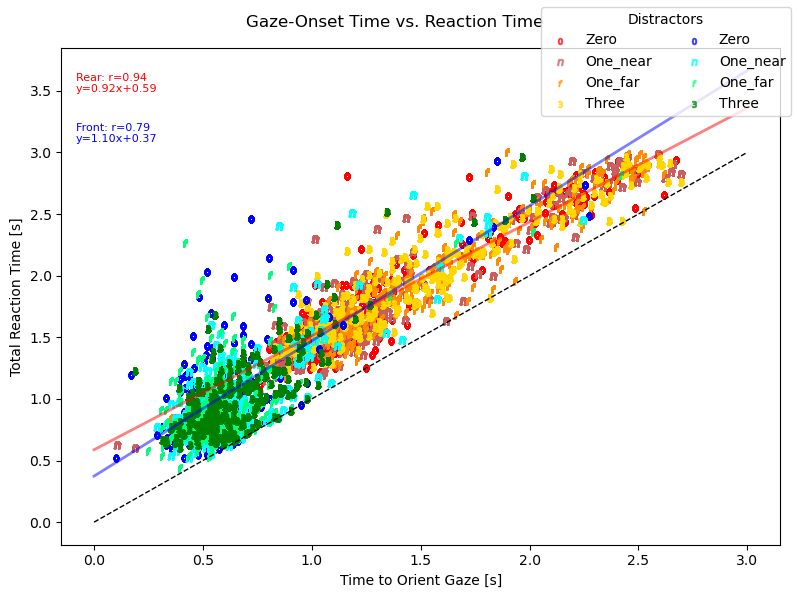

In [9]:
#Figure 8

reload(visualizations)

visualizations.plot_reaction_vs_gazeOnset_time(df_trials)

##### Statisical analysis on gaze distribution

In [10]:
import pandas as pd
from scipy.stats import mannwhitneyu

In [11]:
#mannwhitney U tests on eyetracking distribution on distractor

# For Front position
df_front = df_eyetrack_preprocessed_merged[
    df_eyetrack_preprocessed_merged["position"] == "Front"
]
def mannwhitney_table(groups, comparisons):
    """
    groups: dict of {group_name: pd.Series}
    comparisons: list of tuples of group names to compare
    returns: pandas DataFrame in APA-style format
    """
    rows = []
    for g1, g2 in comparisons:
        data1 = groups[g1]
        data2 = groups[g2]
        stat, p = mannwhitneyu(data1, data2, alternative='two-sided')
        # Calculate z for effect size r
        n1 = len(data1)
        n2 = len(data2)
        mean_U = n1*n2/2
        std_U = np.sqrt(n1*n2*(n1+n2+1)/12)
        z = (stat - mean_U) / std_U
        # After getting U statistic
        #z = norm.ppf(p/2) * (-1 if stat > mean_U else 1)
        r = abs(z)/np.sqrt(n1+n2)
        rows.append({
            "Variable": f"{g1} vs {g2}",
            f"{g1} median": data1.median(),
            f"{g2} median": data2.median(),
            "n1": n1,
            "n2": n2,
            "U": stat,
            "z": round(z, 2),
            "p": round(p, 3),
            "r": round(r, 2)
        })
    return pd.DataFrame(rows)

# Create groups for valid vs invalid comparisons for each distractor type
front_groups = {
    # Zero distractors
    "Valid_Zero": df_front[(df_front["nb_dist"] == "Zero") & (df_front["condition"] == "Valid")]["rEyeYaw"],
    "Invalid_Zero": df_front[(df_front["nb_dist"] == "Zero") & (df_front["condition"] == "Invalid")]["rEyeYaw"],
    
    # One_near distractors
    "Valid_One_near": df_front[(df_front["nb_dist"] == "One_near") & (df_front["condition"] == "Valid")]["rEyeYaw"],
    "Invalid_One_near": df_front[(df_front["nb_dist"] == "One_near") & (df_front["condition"] == "Invalid")]["rEyeYaw"],
    
    # One_far distractors
    "Valid_One_far": df_front[(df_front["nb_dist"] == "One_far") & (df_front["condition"] == "Valid")]["rEyeYaw"],
    "Invalid_One_far": df_front[(df_front["nb_dist"] == "One_far") & (df_front["condition"] == "Invalid")]["rEyeYaw"],
    
    # Three distractors
    "Valid_Three": df_front[(df_front["nb_dist"] == "Three") & (df_front["condition"] == "Valid")]["rEyeYaw"],
    "Invalid_Three": df_front[(df_front["nb_dist"] == "Three") & (df_front["condition"] == "Invalid")]["rEyeYaw"]
}

# For Rear position
df_rear = df_eyetrack_preprocessed_merged[
    df_eyetrack_preprocessed_merged["position"] == "Rear"
]

rear_groups = {
    # Zero distractors
    "Valid_Zero": df_rear[(df_rear["nb_dist"] == "Zero") & (df_rear["condition"] == "Valid")]["rEyeYaw"],
    "Invalid_Zero": df_rear[(df_rear["nb_dist"] == "Zero") & (df_rear["condition"] == "Invalid")]["rEyeYaw"],
    
    # One_near distractors
    "Valid_One_near": df_rear[(df_rear["nb_dist"] == "One_near") & (df_rear["condition"] == "Valid")]["rEyeYaw"],
    "Invalid_One_near": df_rear[(df_rear["nb_dist"] == "One_near") & (df_rear["condition"] == "Invalid")]["rEyeYaw"],
    
    # One_far distractors
    "Valid_One_far": df_rear[(df_rear["nb_dist"] == "One_far") & (df_rear["condition"] == "Valid")]["rEyeYaw"],
    "Invalid_One_far": df_rear[(df_rear["nb_dist"] == "One_far") & (df_rear["condition"] == "Invalid")]["rEyeYaw"],
    
    # Three distractors
    "Valid_Three": df_rear[(df_rear["nb_dist"] == "Three") & (df_rear["condition"] == "Valid")]["rEyeYaw"],
    "Invalid_Three": df_rear[(df_rear["nb_dist"] == "Three") & (df_rear["condition"] == "Invalid")]["rEyeYaw"]
}

# Define comparisons for valid vs invalid for each distractor type
comparisons_valid_invalid = [
    ("Valid_Zero", "Invalid_Zero"),
    ("Valid_One_near", "Invalid_One_near"),
    ("Valid_One_far", "Invalid_One_far"),
    ("Valid_Three", "Invalid_Three")
]

# Generate tables using your existing function
table_front_valid_invalid = mannwhitney_table(front_groups, comparisons_valid_invalid)
table_rear_valid_invalid = mannwhitney_table(rear_groups, comparisons_valid_invalid)

print("Front position - Valid vs Invalid comparisons:\n", table_front_valid_invalid)
print("\nRear position - Valid vs Invalid comparisons:\n", table_rear_valid_invalid)

# If you also want to compare between distractor types within validity conditions,
# you can create additional comparisons:
comparisons_within_valid = [
    ("Valid_Zero", "Valid_One_near"),
    ("Valid_Zero", "Valid_One_far"),
    ("Valid_Zero", "Valid_Three"),
    ("Valid_One_near", "Valid_One_far"),
    ("Valid_One_near", "Valid_Three"),
    ("Valid_One_far", "Valid_Three")
]

comparisons_within_invalid = [
    ("Invalid_Zero", "Invalid_One_near"),
    ("Invalid_Zero", "Invalid_One_far"),
    ("Invalid_Zero", "Invalid_Three"),
    ("Invalid_One_near", "Invalid_One_far"),
    ("Invalid_One_near", "Invalid_Three"),
    ("Invalid_One_far", "Invalid_Three")
]

print("\nFront - Within Valid condition:\n", mannwhitney_table(front_groups, comparisons_within_valid))
print("\nFront - Within Invalid condition:\n", mannwhitney_table(front_groups, comparisons_within_invalid))
print("\nRear - Within Valid condition:\n", mannwhitney_table(rear_groups, comparisons_within_valid))
print("\nRear - Within Invalid condition:\n", mannwhitney_table(rear_groups, comparisons_within_invalid))

Front position - Valid vs Invalid comparisons:
                              Variable  Valid_Zero median  Invalid_Zero median  \
0          Valid_Zero vs Invalid_Zero          21.819113             9.706778   
1  Valid_One_near vs Invalid_One_near                NaN                  NaN   
2    Valid_One_far vs Invalid_One_far                NaN                  NaN   
3        Valid_Three vs Invalid_Three                NaN                  NaN   

      n1    n2           U      z    p     r  Valid_One_near median  \
0  12811  3611  25896007.5  10.99  0.0  0.09                    NaN   
1  13320  3639  27046004.0  10.74  0.0  0.08               6.161261   
2  12824  3437  23067437.0   4.21  0.0  0.03                    NaN   
3  13518  3475  25906056.0   9.38  0.0  0.07                    NaN   

   Invalid_One_near median  Valid_One_far median  Invalid_One_far median  \
0                      NaN                   NaN                     NaN   
1                 2.125255            

### Early gaze

In [7]:
#Dataframe for early gaze analysis

results = []

for trial_id in df_eyetrack_preprocessed_merged["trial"].unique():
    trial_df = (df_eyetrack_preprocessed_merged
                [df_eyetrack_preprocessed_merged["trial"] == trial_id]
                .sort_values("timeSinceTrialStart")
                .reset_index(drop=True))

    row0        = trial_df.iloc[0]
    participant = row0["participant"]
    condition   = row0["condition"]
    position    = row0["position"]
    nb_dist     = row0["nb_dist"]

    window = trial_df[trial_df["timeSinceTrialStart"] <= 0.2]

    if len(window) < 2:
        mean_yaw = np.nan
    else:
        mean_yaw = window["rEyeYaw"].mean()

    results.append({
        "trial":        trial_id,
        "participant":  participant,
        "condition":    condition,
        "position":     position,
        "nb_dist":      nb_dist,
        "mean_yaw":     mean_yaw,
        "n_samples":    len(window),  # sanity check — should be ~10
    })

df_early_gaze = pd.DataFrame(results)
print(df_early_gaze["n_samples"].describe().round(1))  # verify ~10 samples per trial
print(df_early_gaze.groupby(["position", "condition", "nb_dist"])["mean_yaw"].mean().round(3))

count    2784.0
mean       10.0
std         0.0
min        10.0
25%        10.0
50%        10.0
75%        10.0
max        10.0
Name: n_samples, dtype: float64
position  condition  nb_dist 
Front     Invalid    One_far     0.251
                     One_near    1.378
                     Three       1.346
                     Zero        0.443
          Valid      One_far     0.060
                     One_near    0.284
                     Three       0.835
                     Zero        0.328
Rear      Invalid    One_far     0.393
                     One_near    0.578
                     Three      -0.780
                     Zero       -0.516
          Valid      One_far     0.345
                     One_near    1.133
                     Three       0.088
                     Zero        0.346
Name: mean_yaw, dtype: float64


### Early gaze analysis

start of a trial is the soundTime = start of the sound cue, lasting 150 ms. Afterwhich target appears.
High number of samples because frequency of 50 Hz over 300 ms x 2784


In [8]:
# Dataframe for ealy gaze analysis

# Extract raw yaw samples within the 300ms window for each trial
results = []

for trial_id in df_eyetrack_preprocessed_merged["trial"].unique():
    trial_df = (df_eyetrack_preprocessed_merged
                [df_eyetrack_preprocessed_merged["trial"] == trial_id]
                .sort_values("timeSinceTrialStart")
                .reset_index(drop=True))

    row0        = trial_df.iloc[0]
    participant = row0["participant"]
    condition   = row0["condition"]
    position    = row0["position"]
    nb_dist     = row0["nb_dist"]

    window = trial_df[trial_df["timeSinceTrialStart"] <= 0.300] #change here for the window

    for _, sample in window.iterrows():
        results.append({
            "trial":               trial_id,
            "participant":         participant,
            "condition":           condition,
            "position":            position,
            "nb_dist":             nb_dist,
            "timeSinceTrialStart": sample["timeSinceTrialStart"],
            "rEyeYaw":             sample["rEyeYaw"],
        })

df_raw_yaw = pd.DataFrame(results)
df_raw_yaw.to_csv("R_script_eyeTracking/Dataframes-used/raw_yaw_for_R.csv", index=False)
print(df_raw_yaw.shape)
print(df_raw_yaw.head())

(41754, 7)
   trial participant condition position   nb_dist  timeSinceTrialStart  \
0      1          18   Invalid     Rear  One_near             0.000000   
1      1          18   Invalid     Rear  One_near             0.020447   
2      1          18   Invalid     Rear  One_near             0.041504   
3      1          18   Invalid     Rear  One_near             0.061920   
4      1          18   Invalid     Rear  One_near             0.082428   

    rEyeYaw  
0  0.043901  
1  0.256284  
2  0.173548  
3  0.134883  
4  0.094980  


##### Gaze onset latency dataframe

In [15]:
DEPARTURE_THRESHOLD = 15  # degrees from center
results = []

for trial_id in df_eyetrack_preprocessed_merged["trial"].unique():
    trial_df = (df_eyetrack_preprocessed_merged
                [df_eyetrack_preprocessed_merged["trial"] == trial_id]
                .sort_values("timeSinceTrialStart")
                .reset_index(drop=True))

    row0        = trial_df.iloc[0]
    participant = row0["participant"]
    condition   = row0["condition"]
    position    = row0["position"]
    nb_dist     = row0["nb_dist"]

    # Distance from center (0,0) at each sample
    trial_df["dist_from_center"] = np.sqrt(
        trial_df["rEyeYaw"]**2 + trial_df["rEyePitch"]**2
    )

    # First sample where gaze exceeds threshold
    departed = trial_df[trial_df["dist_from_center"] > DEPARTURE_THRESHOLD]

    departure_ms = departed.iloc[0]["timeSinceTrialStart"] * 1000 if len(departed) > 0 else np.nan

    results.append({
        "trial":        trial_id,
        "participant":  participant,
        "condition":    condition,
        "position":     position,
        "nb_dist":      nb_dist,
        "departure_ms": departure_ms,
    })

df_departure = pd.DataFrame(results)
print(df_departure["departure_ms"].describe().round(1))
print(df_departure.groupby(["position", "condition"])["departure_ms"].mean().round(1))
print(df_departure.groupby(["position", "nb_dist"])["departure_ms"].mean().round(1))

count    2728.0
mean      377.4
std       177.7
min         0.0
25%       316.1
50%       394.0
75%       479.8
max      1232.3
Name: departure_ms, dtype: float64
position  condition
Front     Invalid      360.6
          Valid        354.1
Rear      Invalid      391.8
          Valid        402.3
Name: departure_ms, dtype: float64
position  nb_dist 
Front     One_far     357.0
          One_near    369.5
          Three       357.8
          Zero        337.5
Rear      One_far     380.9
          One_near    367.3
          Three       379.4
          Zero        471.1
Name: departure_ms, dtype: float64


In [16]:
# Export the dataset
df_departure.to_csv('R_script_eyeTracking/Dataframes-used/departure_latency_data.csv', index=False)
print("✓ Dataset exported to 'departure_latency_data.csv'")
print(f"\nDataset shape: {df_departure.shape}")
print(f"Columns: {df_departure.columns.tolist()}")
print(f"\nFirst few rows:")
print(df_departure.head())

✓ Dataset exported to 'departure_latency_data.csv'

Dataset shape: (2784, 6)
Columns: ['trial', 'participant', 'condition', 'position', 'nb_dist', 'departure_ms']

First few rows:
   trial participant condition position   nb_dist  departure_ms
0      1          18   Invalid     Rear  One_near    472.198486
1      3          18     Valid     Rear   One_far    389.495850
2      4          18     Valid     Rear     Three    535.003662
3      5          18     Valid     Rear      Zero    680.938721
4      6          18     Valid    Front   One_far    515.655518


### Time to reach AOI
Repport : https://docs.google.com/document/d/1aC4iBA2CnMUaamhzMyuljCF-y62gUM3IziHJv7TOA9s/edit?usp=sharing


##### Dwell initialisation

In [17]:
#time until interest dwell 
def compute_dwell(trial_df,
                  target_yaw, target_pitch,
                  aoi_radius=20,
                  time_col="timeSinceTrialStart"):
    """
    Returns a dict with:
      - first_entry_time : when gaze first entered the AOI (ms), or NaN
      - visits           : list of dicts {entry_time, exit_time, duration}
      - total_dwell      : total time spent in AOI across all visits (ms)
    """
    t     = trial_df[time_col].values
    yaw   = trial_df["rEyeYaw"].values
    pitch = trial_df["rEyePitch"].values

    # Step 1 — is gaze inside AOI at each sample?
    dist     = np.sqrt((yaw - target_yaw)**2 + (pitch - target_pitch)**2)
    in_aoi   = dist < aoi_radius

    # Step 2 — group consecutive samples
    groups = (in_aoi != np.roll(in_aoi, 1)).cumsum()

    visits = []

    for g in np.unique(groups):
        mask = groups == g
        if not in_aoi[mask][0]:       # outside AOI → skip
            continue
        entry_time = t[mask].min()
        exit_time  = t[mask].max()
        duration   = exit_time - entry_time
        visits.append({
            "entry_time": entry_time,
            "exit_time":  exit_time,
            "duration":   duration
        })

    first_entry = visits[0]["entry_time"] if visits else np.nan
    total_dwell = sum(v["duration"] for v in visits) if visits else 0

    return {
        "first_entry_time": first_entry,
        "visits":           visits,
        "total_dwell":      total_dwell
    }

In [18]:
target_mapping = {
    ('Front', 'Right'): (42,  -12.1),
    ('Front', 'Left'):  (42,   -12.1),   # same yaw as Right, flipped in preprocessing
    ('Rear',  'Right'): (136, -15.0),
    ('Rear',  'Left'):  (136, -15.0),   # same yaw as Right, flipped in preprocessing
}

time_col = "timeSinceTrialStart"
df = df_eyetrack_preprocessed_merged


results = []

for trial_id in df["trial"].unique():
    trial_df = df[df["trial"] == trial_id].sort_values(time_col)

    # get your target yaw/pitch for this trial as usual
    position      = trial_df["position"].iloc[0]
    lateralisation = trial_df["lateralisation"].iloc[0]
    target_yaw, target_pitch = target_mapping[(position, lateralisation)]

    dwell = compute_dwell(trial_df, target_yaw, target_pitch)
    
    # gaze at end of trial
    last_row       = trial_df.iloc[-1]
    gaze_end_yaw   = last_row["rEyeYaw"]
    gaze_end_pitch = last_row["rEyePitch"]
    dist_at_end    = np.sqrt(
        (gaze_end_yaw   - target_yaw)**2 +
        (gaze_end_pitch - target_pitch)**2
    )

    results.append({
        "trial":            trial_id,
        "participant":      trial_df["participant"].iloc[0],
        "condition":        trial_df["condition"].iloc[0],
        "position":         position,
        "lateralisation":   lateralisation,
        "nb_dist":          trial_df["nb_dist"].iloc[0],
        "first_entry_ms":   dwell["first_entry_time"],
        "total_dwell_ms":   dwell["total_dwell"],
        "n_visits":         len(dwell["visits"]),
        "gaze_end_yaw":     gaze_end_yaw,
        "gaze_end_pitch":   gaze_end_pitch,
        "dist_at_end":      dist_at_end
    })



df_dwell = pd.DataFrame(results)
print('done')

done


In [19]:
print(f"Total trials: {len(df_dwell)}")
print(f"NaN first_entry_ms: {df_dwell['first_entry_ms'].isna().sum()}")
print(f"NaN total_dwell_ms: {df_dwell['total_dwell_ms'].isna().sum()}")
print(f"\nNaN rate: {df_dwell['first_entry_ms'].isna().mean()*100:.1f}%")

Total trials: 2784
NaN first_entry_ms: 188
NaN total_dwell_ms: 0

NaN rate: 6.8%


In [20]:
#to se lmer in R need this df
df_dwell.to_csv('R_script_eyeTracking/Dataframes-used/df_dwell_raw.csv', index=False)
print("Saved!")

Saved!
